# Transfer Learning with Autoencoders and t-SNE

### Import Libraries

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Reshape, UpSampling2D
from tensorflow.keras.models import Model
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random

###  Load and Preprocess Data

In [2]:
def load_images_from_multiple_folders(base_folder, img_size=(128, 128), num_folders=6):
    images = []
    total_images = 0

    # List all the folder names inside the base folder
    all_folders = [folder_name for folder_name in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, folder_name))]
    
    # Randomly sample 'num_folders' folders
    selected_folders = random.sample(all_folders, num_folders)
    
    for folder_name in selected_folders:
        folder_path = os.path.join(base_folder, folder_name, 'images')
        
        # Check if 'images' folder exists within the selected folder
        if os.path.exists(folder_path):
            folder_images_count = 0
            print(f"Loading images from folder: {folder_name}")
            
            # Loop through the image files in the selected folder
            for filename in os.listdir(folder_path):
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                
                if img is not None:
                    img = cv2.resize(img, img_size)  # Resize to the desired size
                    img = img.astype("float32") / 255.0  # Normalize pixel values to [0, 1]
                    images.append(img)
                    folder_images_count += 1
            print(f"  Loaded {folder_images_count} images from folder {folder_name}")
            total_images += folder_images_count

    print(f"Total Chest X-Ray images loaded: {total_images}")
    return np.array(images)

In [3]:
base_chest_xray_path = '/kaggle/input/data'
chest_xray_images = load_images_from_multiple_folders(base_chest_xray_path)
# Reshape to add channel dimension for model compatibility
chest_xray_images = np.expand_dims(chest_xray_images, axis=-1)
print("Chest X-Ray Images shape:", chest_xray_images.shape)

Loading images from folder: images_011
  Loaded 10000 images from folder images_011
Loading images from folder: images_008
  Loaded 10000 images from folder images_008
Loading images from folder: images_003
  Loaded 10000 images from folder images_003
Loading images from folder: images_004
  Loaded 10000 images from folder images_004
Loading images from folder: images_005
  Loaded 10000 images from folder images_005
Loading images from folder: images_002


libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


  Loaded 10000 images from folder images_002
Total Chest X-Ray images loaded: 60000
Chest X-Ray Images shape: (60000, 128, 128, 1)


### Splitting the dataset in to training,validation and test set

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

# Shuffle and split the dataset
train_size = 0.7
val_size = 0.15
test_size = 0.15

# First, split the data into train and temporary sets
train_images, temp_images = train_test_split(chest_xray_images, train_size=train_size, random_state=42)

# Then, split the temporary set into validation and test sets
val_images, test_images = train_test_split(temp_images, test_size=test_size / (test_size + val_size), random_state=42)

print("Train images shape:", train_images.shape)
print("Validation images shape:", val_images.shape)
print("Test images shape:", test_images.shape)


Train images shape: (42000, 128, 128, 1)
Validation images shape: (9000, 128, 128, 1)
Test images shape: (9000, 128, 128, 1)


###  Define the Autoencoder model with convolutional layers

In [5]:
def build_autoencoder(input_shape=(128, 128, 1)):
    # Encoder
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = Model(inputs, decoded)
    return autoencoder




### Train the autoencoder on Chest X-Ray images

In [6]:
autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')

In [7]:
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint_callback = ModelCheckpoint(
    "/kaggle/working/best_chest.keras", 
    monitor="val_loss", 
    save_best_only=True, 
    verbose=1
)

# Early stopping callback to prevent overfitting if validation loss stops improving
early_stopping_callback = EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True, 
    verbose=1)

In [9]:
# Train the autoencoder
epochs = 100
batch_size = 12
auto_hist = autoencoder.fit(train_images, train_images, 
                          epochs=epochs,
                          batch_size=batch_size, 
                          validation_data=(val_images, val_images), 
                          verbose=1,  callbacks=[checkpoint_callback, early_stopping_callback])

Epoch 1/100


I0000 00:00:1731933215.450596     105 service.cc:145] XLA service 0x7a601c00c2a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731933215.450658     105 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  22/3500 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - loss: 0.0531

I0000 00:00:1731933219.016745     105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3494/3500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0038
Epoch 1: val_loss improved from inf to 0.00095, saving model to /kaggle/working/best_chest.keras
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 37s 9ms/step - loss: 0.0038 - val_loss: 9.4509e-04
Epoch 2/100
3496/3500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9548e-04
Epoch 2: val_loss improved from 0.00095 to 0.00078, saving model to /kaggle/working/best_chest.keras
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 8.9541e-04 - val_loss: 7.7896e-04
Epoch 3/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.3002e-04
Epoch 3: val_loss improved from 0.00078 to 0.00066, saving model to /kaggle/working/best_chest.keras
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 7.3002e-04 - val_loss: 6.6023e-04
Epoch 4/100
3494/3500 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.4853e-04
Epoch 4: val_loss improved from 0.00066 to 0.00058, saving model to /kaggle/working/best_chest.keras
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 6.4849e-04 - v

In [10]:
#Saving the Autoencoder and Only Encoder part of the network for tuning with covid dataset
autoencoder.save("nih_autoencoder.h5")
encoder = Model(autoencoder.input, autoencoder.layers[6].output)  # Encoder up to the bottleneck layer
encoder.save("nih_encoder.h5")

# **Calculating and plotting autoencoder parameters for 100 Epochs**

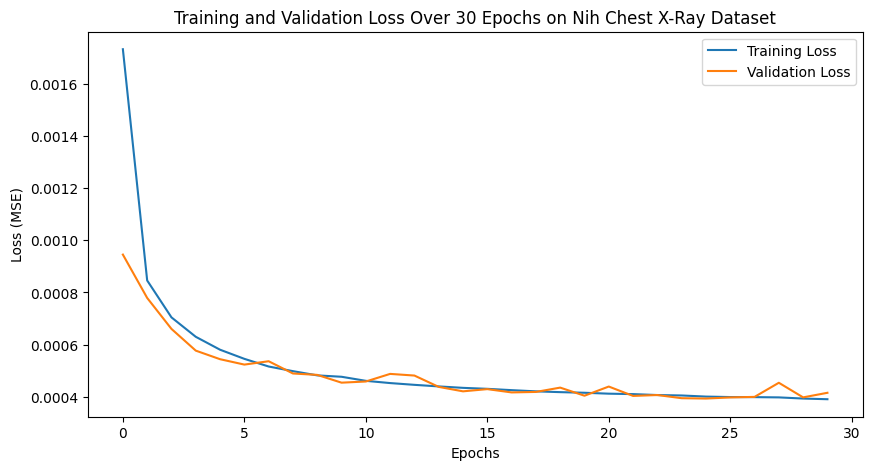

In [135]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(auto_hist.history['loss'], label='Training Loss')
plt.plot(auto_hist.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss Over 30 Epochs on Nih Chest X-Ray Dataset")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


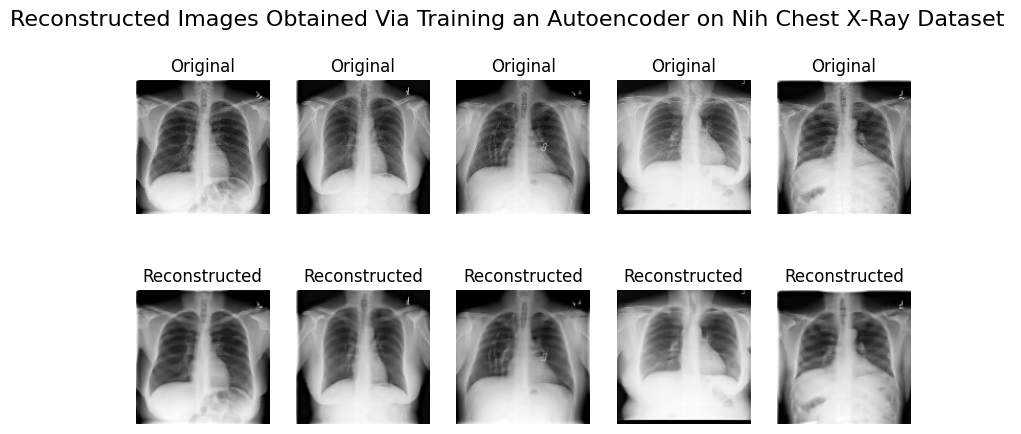

In [133]:
import matplotlib.pyplot as plt
# Select a few images from the validation set
num_images = 5  # Number of images to display
sample_images = test_images[:num_images]

# Generate reconstructed images from the autoencoder
reconstructed_images = autoencoder.predict(sample_images)

# Plot the original and reconstructed images side by side
plt.figure(figsize=(10, 5))
plt.suptitle("Reconstructed Images Obtained Via Training an Autoencoder on Nih Chest X-Ray Dataset ", fontsize=16)
for i in range(num_images):
    # Display original image
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(sample_images[i].reshape(128, 128), cmap='gray')
    plt.title("Original")
    plt.axis("off")
    
    # Display reconstructed image
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(reconstructed_images[i].reshape(128, 128), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 147ms/step


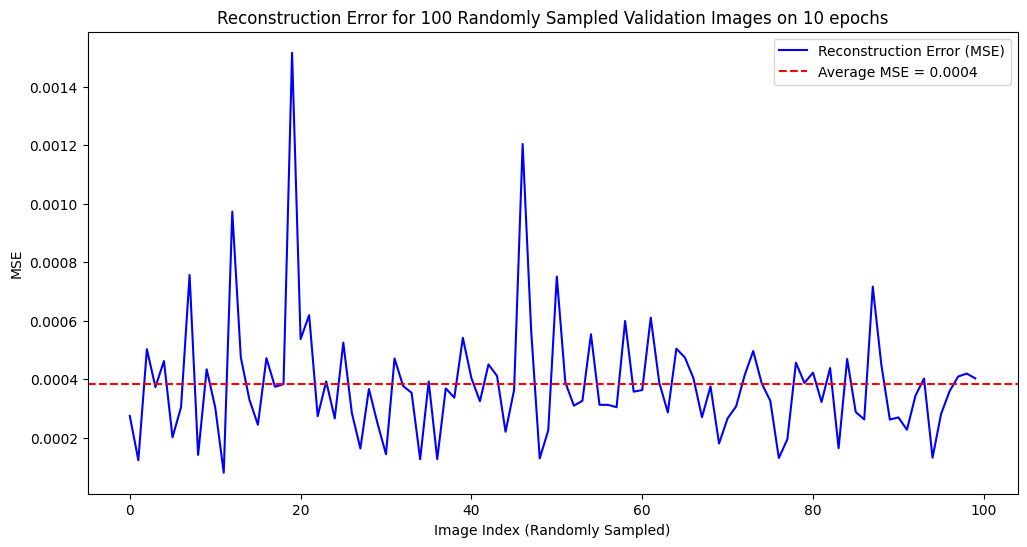

Average MSE Reconstruction Error for Randomly Sampled 100 Images: 0.0004


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Randomly select 100 images from the validation set
num_images = 100
random_indices = np.random.choice(len(test_images), num_images, replace=False)
sample_images = test_images[random_indices]
reconstructed_images = autoencoder.predict(sample_images)

# Calculate the Mean Squared Error (MSE) for each randomly selected image
mse_errors = []
for original, reconstructed in zip(sample_images, reconstructed_images):
    error = mean_squared_error(original.flatten(), reconstructed.flatten())
    mse_errors.append(error)

# Calculate the average MSE for the 100 randomly selected images
average_mse = np.mean(mse_errors)

# Plot the MSE error for each of the randomly selected images
plt.figure(figsize=(12, 6))
plt.plot(range(num_images), mse_errors, label="Reconstruction Error (MSE)", color='blue')
plt.axhline(y=average_mse, color='red', linestyle='--', label=f"Average MSE = {average_mse:.4f}")
plt.xlabel("Image Index (Randomly Sampled)")
plt.ylabel("MSE")
plt.title("Reconstruction Error for 100 Randomly Sampled Validation Images on 10 epochs")
plt.legend()
plt.show()

# Print the average reconstruction error
print(f"Average MSE Reconstruction Error for Randomly Sampled 100 Images: {average_mse:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


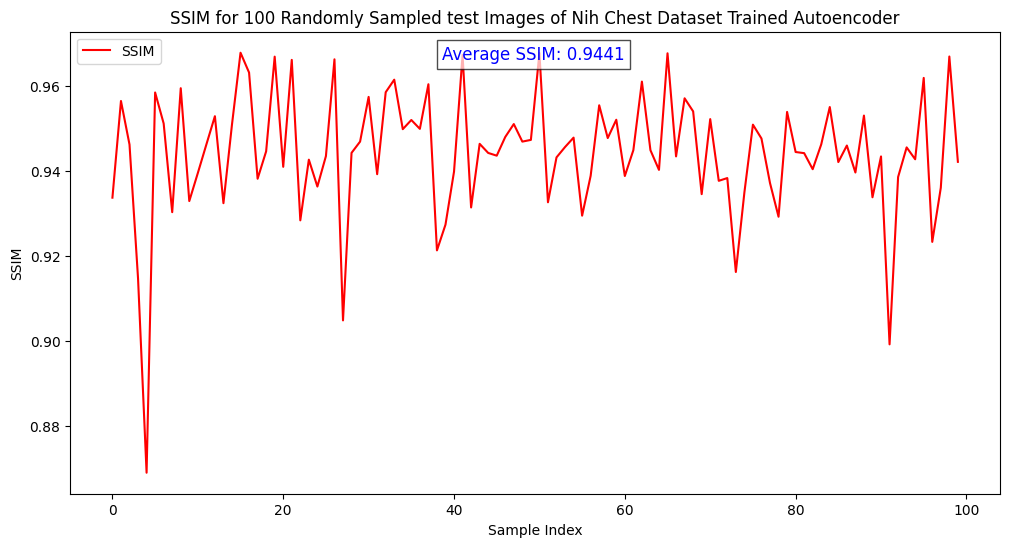

In [128]:
from skimage.metrics import structural_similarity as ssim

# Number of images to randomly sample
num_images = 100
random_indices = np.random.choice(len(test_images), num_images, replace=False)
sample_images = test_images[random_indices]
reconstructed_images = autoencoder.predict(sample_images)

# Calculate SSIM for each pair of original and reconstructed images
ssim_scores = []
for original, reconstructed in zip(sample_images, reconstructed_images):
    score = ssim(original.squeeze(), reconstructed.squeeze(), data_range=1)
    ssim_scores.append(score)

# Calculate the average SSIM
average_ssim = np.mean(ssim_scores)

# Plot the SSIM scores for each of the 100 randomly sampled images
plt.figure(figsize=(12, 6))
plt.plot(range(num_images), ssim_scores, label="SSIM", color='red')
plt.xlabel("Sample Index")
plt.ylabel("SSIM")
plt.title("SSIM for 100 Randomly Sampled test Images of Nih Chest Dataset Trained Autoencoder")
plt.legend()

# Display the average SSIM inside the plot
plt.text(0.4, 0.94, f"Average SSIM: {average_ssim:.4f}", transform=plt.gca().transAxes, 
         fontsize=12, color='blue', bbox=dict(facecolor='white', alpha=0.7))

plt.show()

# **Checking latent feature of Autoencoder with Covid DataSet without Tuning**

In [15]:
def load_images_from_folder(folder, img_size=(128, 128)):
    images = []
    count = 0
    print("Loading images from COVID-19 folder")
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img = cv2.resize(img, img_size)  # Resize to the desired size
            img = img.astype("float32") / 255.0  # Normalize pixel values to [0, 1]
            images.append(img)
            count += 1
    print(f"Total COVID-19 images loaded: {count}")
    return np.array(images)

In [16]:
covid_images_path = '/kaggle/input/covid19-radiography-database/COVID-19_Radiography_Dataset/COVID/images'
covid_images = load_images_from_folder(covid_images_path)
covid_images = np.expand_dims(covid_images, axis=-1)
print("COVID-19 X-Ray Images shape:", covid_images.shape)

Loading images from COVID-19 folder
Total COVID-19 images loaded: 3616
COVID-19 X-Ray Images shape: (3616, 128, 128, 1)


In [17]:
import numpy as np
from sklearn.model_selection import train_test_split

# Shuffle and split the dataset
x_train = 0.8
x_val = 0.1
x_test = 0.1

# First, split the data into train and temporary sets
x_train, temp_images = train_test_split(covid_images, train_size=x_train, random_state=42)

# Then, split the temporary set into validation and test sets
x_val, x_test = train_test_split(temp_images, test_size=x_test / (x_test + x_val), random_state=42)

print("Train images shape:", x_train.shape)
print("Validation images shape:", x_val.shape)
print("Test images shape:", x_test.shape)


Train images shape: (2892, 128, 128, 1)
Validation images shape: (362, 128, 128, 1)
Test images shape: (362, 128, 128, 1)


In [18]:
chest_latent_features = autoencoder.predict(test_images/10)
covid_latent_features = autoencoder.predict(x_test)

282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step


In [19]:
latent_features = np.concatenate([chest_latent_features, covid_latent_features])
labels = np.array([0] * len(chest_latent_features) + [1] * len(covid_latent_features))

In [20]:
latent_features.shape

(9362, 128, 128, 1)

In [21]:
latent_features_flat_1 = latent_features.reshape(latent_features.shape[0], -1)
print(latent_features_flat_1.shape)  # Should now be (n_samples, n_features)


(9362, 16384)


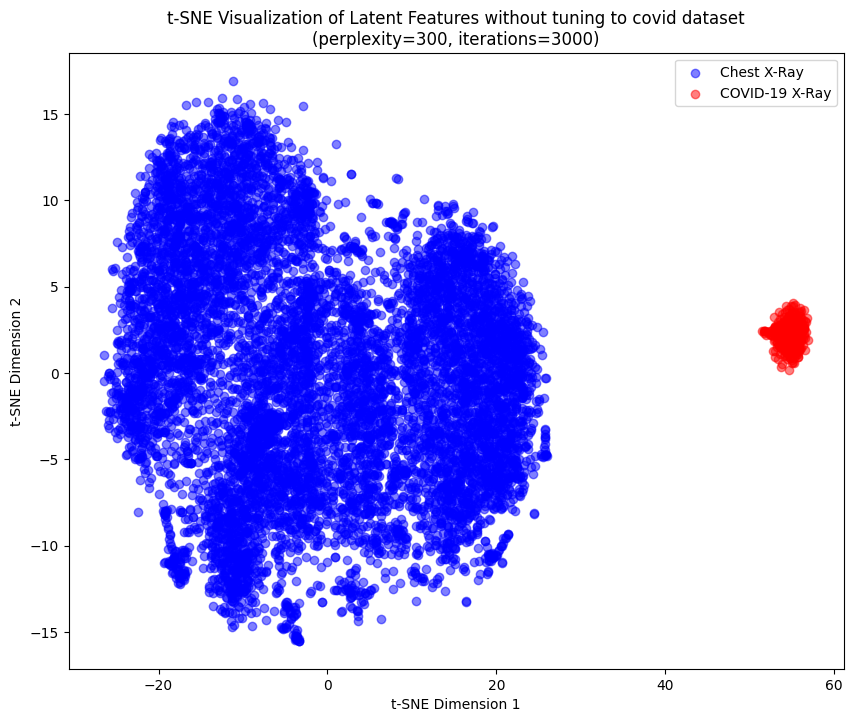

In [22]:
# Ensure labels is a NumPy array
labels = np.array(labels)

# t-SNE parameters
perplexity = 300
n_iter = 3000

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=42)
tsne_results = tsne.fit_transform(latent_features_flat_1)

# Plot t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results[labels == 0, 0], tsne_results[labels == 0, 1], 
            label="Chest X-Ray", alpha=0.5, color='blue')
plt.scatter(tsne_results[labels == 1, 0], tsne_results[labels == 1, 1], 
            label="COVID-19 X-Ray", alpha=0.5, color='red')
plt.legend()
plt.title(f"t-SNE Visualization of Latent Features without tuning to covid dataset\n(perplexity={perplexity}, iterations={n_iter})")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()


# Freezing the encoder part of the autoencoder and training decoder on covid dataset

In [23]:
encoder = keras.models.load_model('/kaggle/working/nih_encoder.h5')

In [24]:
for layer in encoder.layers:
    layer.trainable = False

# MODAL 1: UpSampling without Regularization

In [25]:
# Add decoder layers for transfer learning
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoder.output)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Modal 2: Adding Dropput and BatchNormalization

In [26]:
modal_1 = Model(encoder.input, decoded)
modal_1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 240,129 (938.00 KB)

 Non-trainable params: 92,672 (362.00 KB)

In [27]:
checkpoint_callback2 = ModelCheckpoint(
    "/kaggle/working/best_fine_tuned.keras", 
    monitor="val_loss", 
    save_best_only=True, 
    verbose=1
)

In [28]:
modal_1.compile(optimizer='adam', loss='mse')
# Fine-tune the autoencoder on covid dataset on 100 epochs
epochs = 100
batch_size = 12

In [29]:
tune_hist=modal_1.fit(x_train, x_train, 
                          epochs=epochs,
                          batch_size=batch_size, 
                          validation_data=(x_val, x_val), 
                          verbose=1,callbacks=[checkpoint_callback2, early_stopping_callback])

Epoch 1/100
240/241 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0084
Epoch 1: val_loss improved from inf to 0.00139, saving model to /kaggle/working/best_fine_tuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0083 - val_loss: 0.0014
Epoch 2/100
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013
Epoch 2: val_loss improved from 0.00139 to 0.00106, saving model to /kaggle/working/best_fine_tuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 3/100
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0010
Epoch 3: val_loss improved from 0.00106 to 0.00093, saving model to /kaggle/working/best_fine_tuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010 - val_loss: 9.3022e-04
Epoch 4/100
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.1306e-04
Epoch 4: val_loss improved from 0.00093 to 0.00080, saving model to /kaggle/working/best_fine_tuned.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.1296e-04 - val_loss: 8.

In [30]:
modal_1.save("covid_nih_autoencoder.h5")

# **Calculating and plotting the tuned Autoencoder parameters for 100 Epochs**

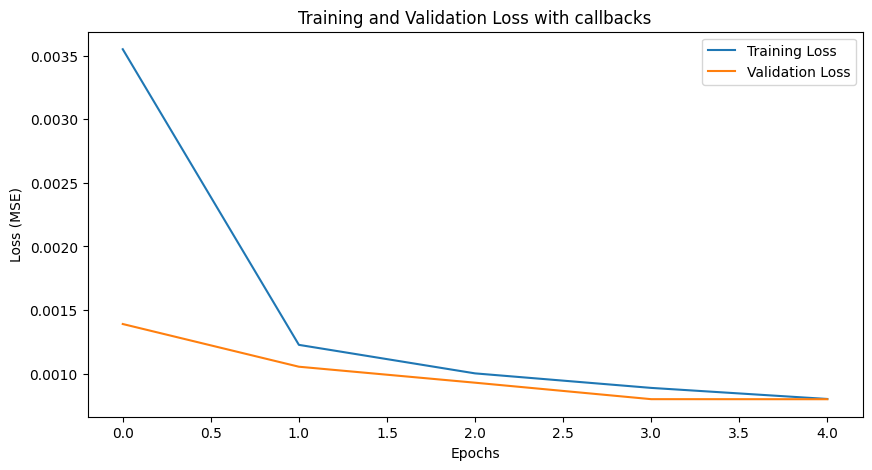

In [125]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(tune_hist.history['loss'], label='Training Loss')
plt.plot(tune_hist.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss with callbacks")
plt.legend()
plt.show()

# Plotting the parameter of tunned autoencoder with covid dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


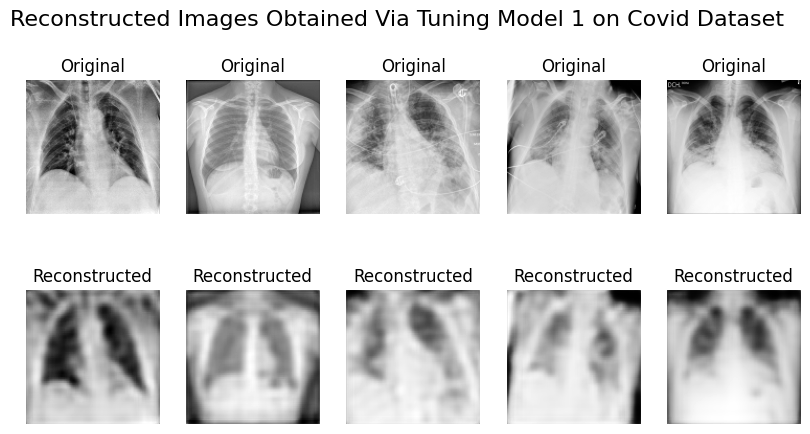

In [124]:
import matplotlib.pyplot as plt

# Select a few images from the validation set
num_images = 5  # Number of images to display
sample_images = x_test[:num_images]

# Generate reconstructed images from the autoencoder
reconstructed_images = modal_1.predict(sample_images)

# Plot the original and reconstructed images side by side
plt.figure(figsize=(10, 5))
plt.suptitle("Reconstructed Images Obtained Via Tuning Model 1 on Covid Dataset ", fontsize=16)

for i in range(num_images):
    # Display original image
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(sample_images[i].reshape(128, 128), cmap='gray')
    plt.title("Original")
    plt.axis("off")
    
    # Display reconstructed image
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(reconstructed_images[i].reshape(128, 128), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


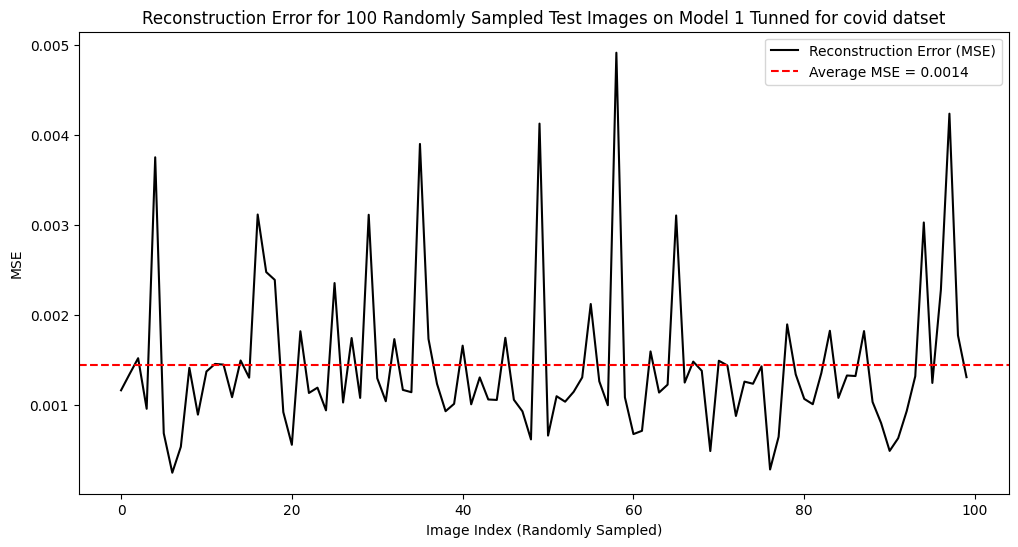

Average MSE Reconstruction Error for Randomly Sampled 100 Images: 0.0014


In [123]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Randomly select 100 images from the validation set
num_images = 100
random_indices = np.random.choice(len(x_test), num_images, replace=False)
sample_images = x_test[random_indices]
reconstructed_images = modal_1.predict(sample_images)

# Calculate the Mean Squared Error (MSE) for each randomly selected image
mse_errors = []
for original, reconstructed in zip(sample_images, reconstructed_images):
    error = mean_squared_error(original.flatten(), reconstructed.flatten())
    mse_errors.append(error)

# Calculate the average MSE for the 100 randomly selected images
average_mse = np.mean(mse_errors)

# Plot the MSE error for each of the randomly selected images
plt.figure(figsize=(12, 6))
plt.plot(range(num_images), mse_errors, label="Reconstruction Error (MSE)", color='black')
plt.axhline(y=average_mse, color='red', linestyle='--', label=f"Average MSE = {average_mse:.4f}")
plt.xlabel("Image Index (Randomly Sampled)")
plt.ylabel("MSE")
plt.title("Reconstruction Error for 100 Randomly Sampled Test Images on Model 1 Tunned for covid datset")
plt.legend()
plt.show()

# Print the average reconstruction error
print(f"Average MSE Reconstruction Error for Randomly Sampled 100 Images: {average_mse:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


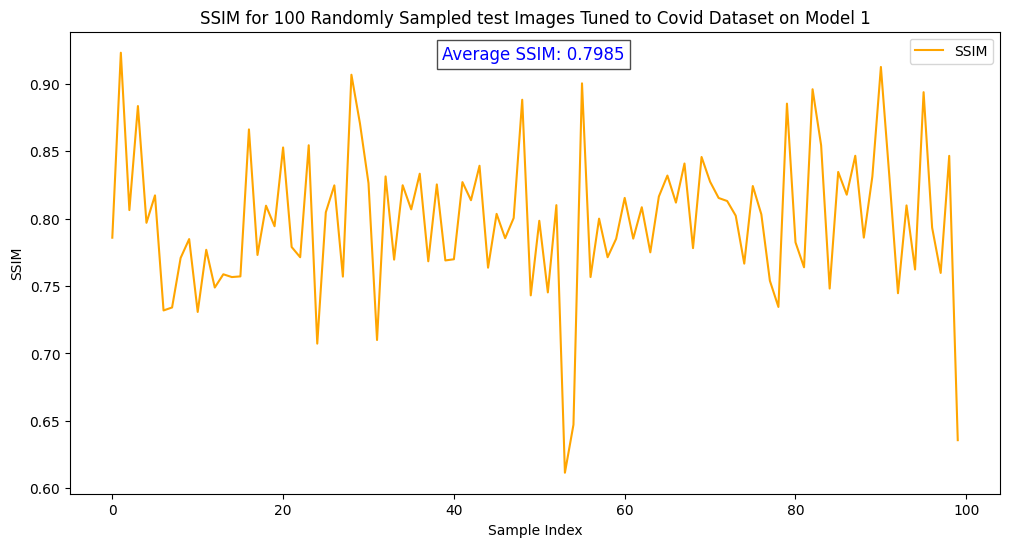

In [122]:
from skimage.metrics import structural_similarity as ssim

# Number of images to randomly sample
num_images = 100
random_indices = np.random.choice(len(test_images), num_images, replace=False)
sample_images = test_images[random_indices]
reconstructed_images = modal_1.predict(sample_images)

# Calculate SSIM for each pair of original and reconstructed images
ssim_scores = []
for original, reconstructed in zip(sample_images, reconstructed_images):
    score = ssim(original.squeeze(), reconstructed.squeeze(), data_range=1)
    ssim_scores.append(score)

# Calculate the average SSIM
average_ssim = np.mean(ssim_scores)

# Plot the SSIM scores for each of the 100 randomly sampled images
plt.figure(figsize=(12, 6))
plt.plot(range(num_images), ssim_scores, label="SSIM", color='orange')
plt.xlabel("Sample Index")
plt.ylabel("SSIM")
plt.title("SSIM for 100 Randomly Sampled test Images Tuned to Covid Dataset on Model 1")
plt.legend()

# Display the average SSIM inside the plot
plt.text(0.4, 0.94, f"Average SSIM: {average_ssim:.4f}", transform=plt.gca().transAxes, 
         fontsize=12, color='blue', bbox=dict(facecolor='white', alpha=0.7))

plt.show()

# **loading the trained Autoencoder model for Evaluation**

In [50]:
covid_latent_features_new = modal_1.predict(x_test)
chest_latent_features_new = modal_1.predict(test_images)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [51]:
latent_features_new = np.concatenate([chest_latent_features_new, covid_latent_features_new])
labels = np.array([0] * len(chest_latent_features_new) + [1] * len(covid_latent_features_new))

In [52]:
latent_features_new.shape

(9362, 128, 128, 1)

In [53]:
latent_features_flat = latent_features_new.reshape(latent_features_new.shape[0], -1)
print(latent_features_flat.shape)  # Should now be (n_samples, n_features)


(9362, 16384)


# Combine features and create labels for t-SNE

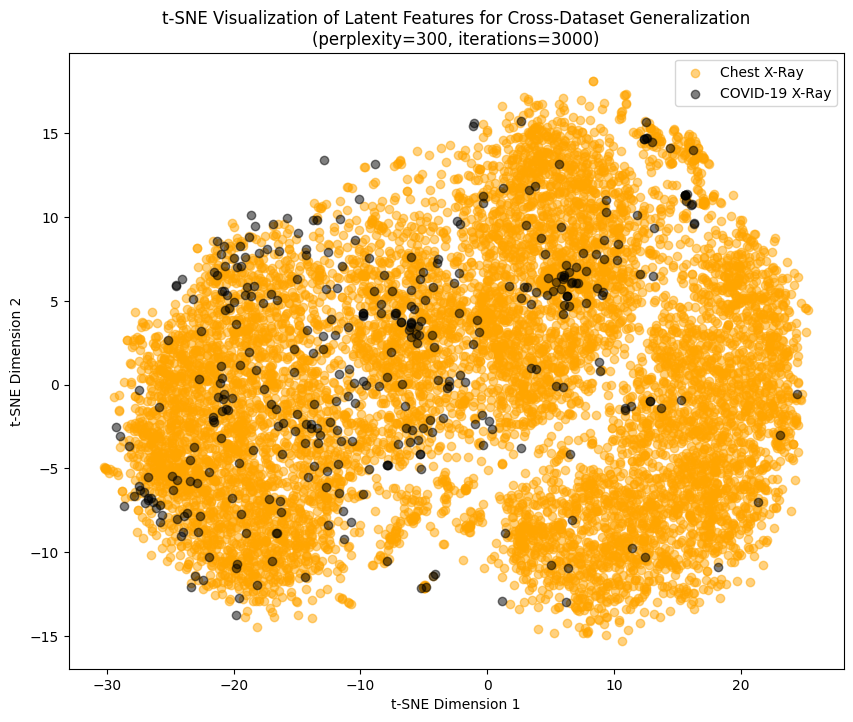

In [54]:
# Ensure labels is a NumPy array
labels = np.array(labels)

# t-SNE parameters
perplexity = 300
n_iter = 3000

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=42)
tsne_results = tsne.fit_transform(latent_features_flat)

# Plot t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results[labels == 0, 0], tsne_results[labels == 0, 1], 
            label="Chest X-Ray", alpha=0.5, color='orange')
plt.scatter(tsne_results[labels == 1, 0], tsne_results[labels == 1, 1], 
            label="COVID-19 X-Ray", alpha=0.5, color='black')
plt.legend()
plt.title(f"t-SNE Visualization of Latent Features for Cross-Dataset Generalization\n(perplexity={perplexity}, iterations={n_iter})")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()

# MODAL 2:Adding Dropput and BatchNormalization for Fine Tuning the Decoder

In [55]:
encoder2 = keras.models.load_model('/kaggle/working/nih_encoder.h5')

In [91]:
from tensorflow.keras.layers import BatchNormalization, Dropout
# Add decoder layers for transfer learning
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoder.output)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.Dropout(0.5)(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

In [92]:
model_2 = Model(encoder.input, decoded)
model_2.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_28 (UpSampling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_29 (UpSampling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_30 (UpSampling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 333,569 (1.27 MB)

 Trainable params: 240,513 (939.50 KB)

 Non-trainable params: 93,056 (363.50 KB)

In [93]:
checkpoint_callback3 = ModelCheckpoint(
    "/kaggle/working/best_fine_tuned_model2.keras", 
    monitor="val_loss", 
    save_best_only=True, 
    verbose=1
)

In [94]:
model_2.compile(optimizer='adam', loss='mse')
# Fine-tune the autoencoder on covid dataset on 50 epochs
epochs = 50
batch_size = 12

In [95]:
tune2_hist=model_2.fit(x_train, x_train, 
                          epochs=epochs,
                          batch_size=batch_size, 
                          validation_data=(x_val, x_val), 
                          verbose=1,callbacks=[checkpoint_callback3])#early_stopping_callback])

Epoch 1/50
234/241 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0212
Epoch 1: val_loss improved from inf to 0.01349, saving model to /kaggle/working/best_fine_tuned_model2.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0209 - val_loss: 0.0135
Epoch 2/50
235/241 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0066
Epoch 2: val_loss improved from 0.01349 to 0.00495, saving model to /kaggle/working/best_fine_tuned_model2.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0066 - val_loss: 0.0050
Epoch 3/50
235/241 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0053
Epoch 3: val_loss improved from 0.00495 to 0.00255, saving model to /kaggle/working/best_fine_tuned_model2.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0053 - val_loss: 0.0026
Epoch 4/50
235/241 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045
Epoch 4: val_loss did not improve from 0.00255
241/241 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0045 - val_loss: 0.0026
Epoch 5/50
235/241 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/s

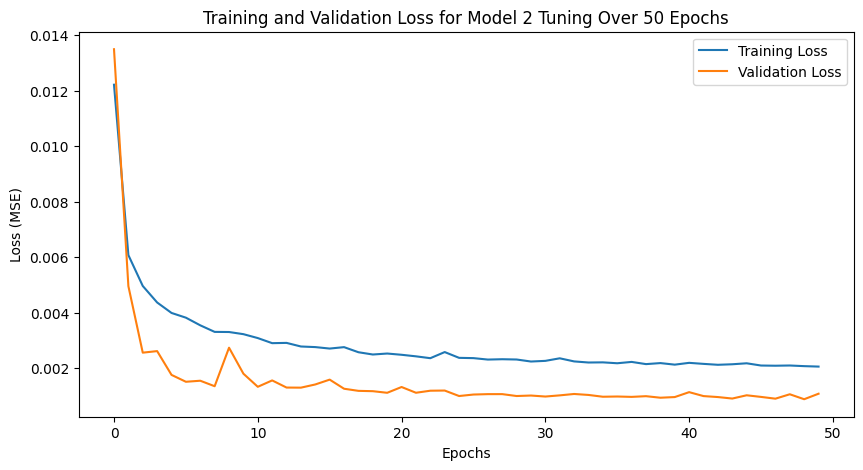

In [120]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(tune2_hist.history['loss'], label='Training Loss')
plt.plot(tune2_hist.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training and Validation Loss for Model 2 Tuning Over 50 Epochs")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


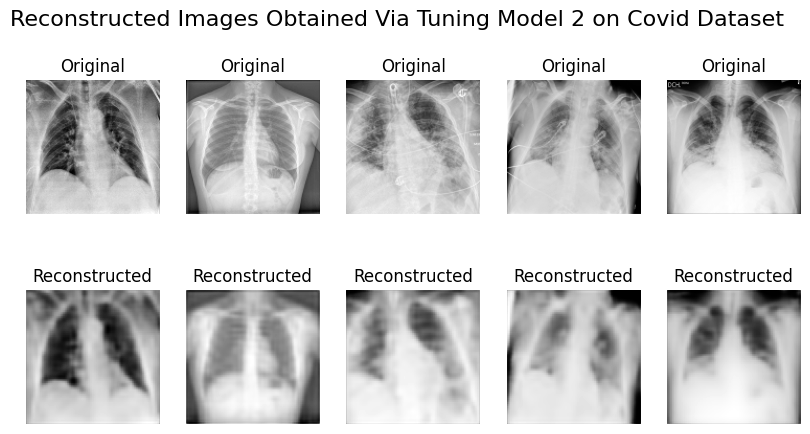

In [119]:
# Select a few images from the test set
num_images = 5  # Number of images to display
sample_images = x_test[:num_images]

# Generate reconstructed images from the autoencoder
reconstructed_images = model_2.predict(sample_images)

# Plot the original and reconstructed images side by side
plt.figure(figsize=(10, 5))

plt.suptitle("Reconstructed Images Obtained Via Tuning Model 2 on Covid Dataset ", fontsize=16)

for i in range(num_images):
    # Display original image
    ax = plt.subplot(2, num_images, i + 1)
    plt.imshow(sample_images[i].reshape(128, 128), cmap='gray')
    plt.title("Original")
    plt.axis("off")
    
    # Display reconstructed image
    ax = plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(reconstructed_images[i].reshape(128, 128), cmap='gray')
    plt.title("Reconstructed")
    plt.axis("off")

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


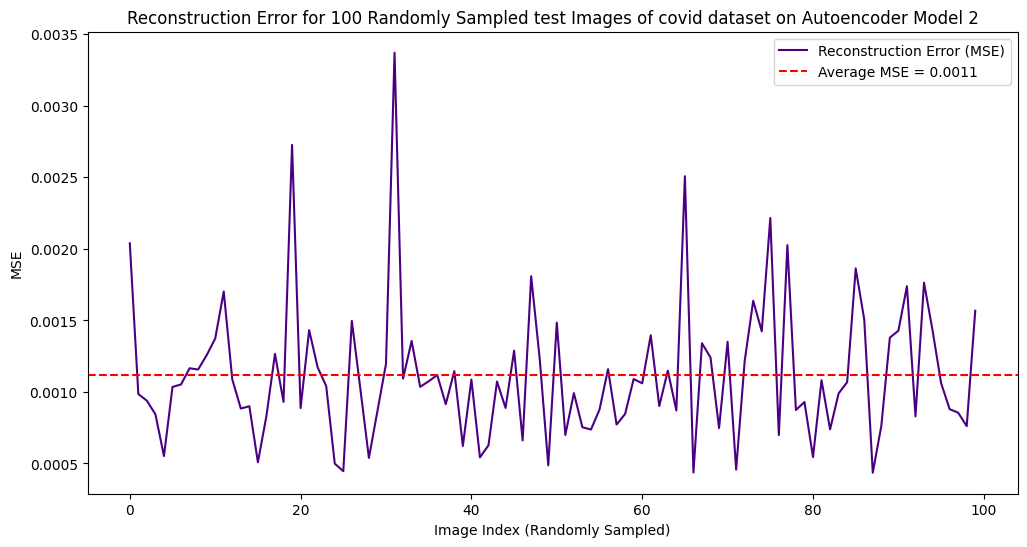

Average MSE Reconstruction Error for Randomly Sampled 100 Images: 0.0011


In [116]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# Randomly select 100 images from the validation set
num_images = 100
random_indices = np.random.choice(len(x_test), num_images, replace=False)
sample_images = x_test[random_indices]
reconstructed_images = model_2.predict(sample_images)

# Calculate the Mean Squared Error (MSE) for each randomly selected image
mse_errors = []
for original, reconstructed in zip(sample_images, reconstructed_images):
    error = mean_squared_error(original.flatten(), reconstructed.flatten())
    mse_errors.append(error)

# Calculate the average MSE for the 100 randomly selected images
average_mse = np.mean(mse_errors)

# Plot the MSE error for each of the randomly selected images
plt.figure(figsize=(12, 6))
plt.plot(range(num_images), mse_errors, label="Reconstruction Error (MSE)", color='indigo')
plt.axhline(y=average_mse, color='red', linestyle='--', label=f"Average MSE = {average_mse:.4f}")
plt.xlabel("Image Index (Randomly Sampled)")
plt.ylabel("MSE")
plt.title("Reconstruction Error for 100 Randomly Sampled test Images of covid dataset on Autoencoder Model 2")
plt.legend()
plt.show()

# Print the average reconstruction error
print(f"Average MSE Reconstruction Error for Randomly Sampled 100 Images: {average_mse:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


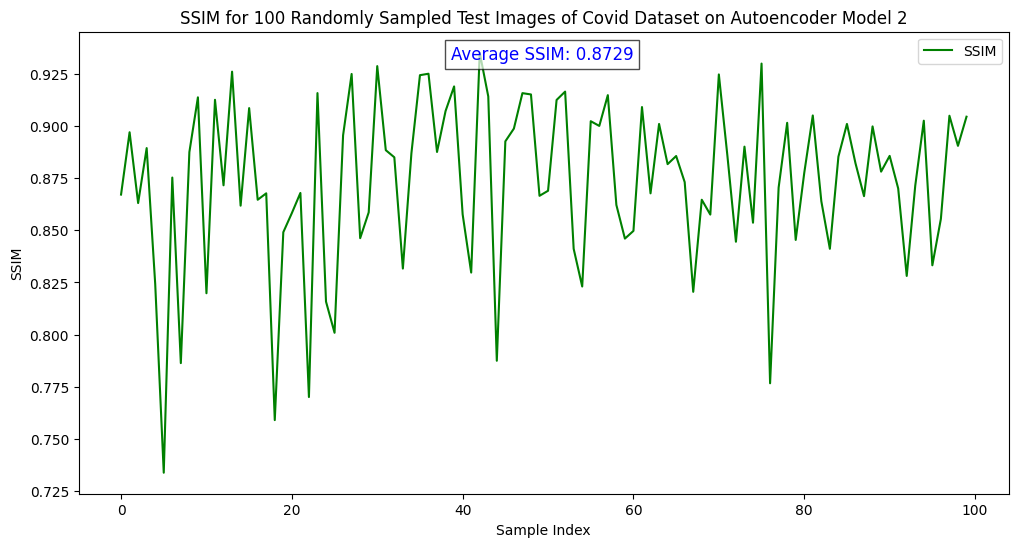

In [115]:
from skimage.metrics import structural_similarity as ssim

# Number of images to randomly sample
num_images = 100
random_indices = np.random.choice(len(x_test), num_images, replace=False)
sample_images = x_test[random_indices]
reconstructed_images = model_2.predict(sample_images)

# Calculate SSIM for each pair of original and reconstructed images
ssim_scores = []
for original, reconstructed in zip(sample_images, reconstructed_images):
    score = ssim(original.squeeze(), reconstructed.squeeze(), data_range=1)
    ssim_scores.append(score)

# Calculate the average SSIM
average_ssim = np.mean(ssim_scores)

# Plot the SSIM scores for each of the 100 randomly sampled images
plt.figure(figsize=(12, 6))
plt.plot(range(num_images), ssim_scores, label="SSIM", color='green')
plt.xlabel("Sample Index")
plt.ylabel("SSIM")
plt.title("SSIM for 100 Randomly Sampled Test Images of Covid Dataset on Autoencoder Model 2")
plt.legend()

# Display the average SSIM inside the plot
plt.text(0.4, 0.94, f"Average SSIM: {average_ssim:.4f}", transform=plt.gca().transAxes, 
         fontsize=12, color='blue', bbox=dict(facecolor='white', alpha=0.7))

plt.show()

# Apply t-SNE for visualization

In [109]:
covid_latent_features_new_2 = model_2.predict(x_test)
chest_latent_features_new_2 = model_2.predict(test_images)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [110]:
latent_features_new_2 = np.concatenate([chest_latent_features_new_2, covid_latent_features_new_2])
labels = np.array([0] * len(chest_latent_features_new_2) + [1] * len(covid_latent_features_new_2))

In [111]:
latent_features_new_2.shape

(9362, 128, 128, 1)

In [112]:
latent_features_flat_3 = latent_features_new_2.reshape(latent_features_new_2.shape[0], -1)
print(latent_features_flat_3.shape)  # Should now be (n_samples, n_features)

(9362, 16384)


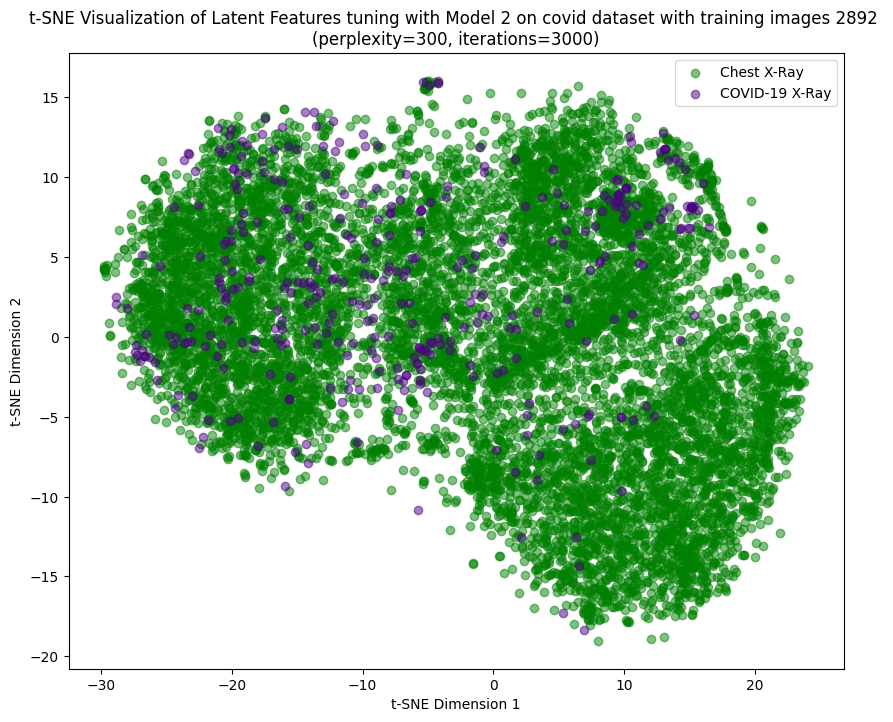

In [113]:
# Ensure labels is a NumPy array
labels = np.array(labels)

# t-SNE parameters
perplexity = 300
n_iter = 3000

# Perform t-SNE
tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=42)
tsne_results = tsne.fit_transform(latent_features_flat_3)

# Plot t-SNE results
plt.figure(figsize=(10, 8))
plt.scatter(tsne_results[labels == 0, 0], tsne_results[labels == 0, 1], 
            label="Chest X-Ray", alpha=0.5, color='green')
plt.scatter(tsne_results[labels == 1, 0], tsne_results[labels == 1, 1], 
            label="COVID-19 X-Ray", alpha=0.5, color='indigo')
plt.legend()
plt.title(f"t-SNE Visualization of Latent Features tuning with Model 2 on covid dataset with training images 2892 \n(perplexity={perplexity}, iterations={n_iter})")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()
